---
title: Multivariate > Factor Analysis
jupyter: python3
---

<div class="alert alert-info">Reduce data dimensionality without significant loss of information.</div>

In [1]:
import polars as pl
import pyrsm as rsm

In [2]:
## setup pyrsm for autoreload
%reload_ext autoreload
%autoreload 2
%aimport pyrsm

## Overview

As stated in the documentation for pre-factor analysis (see _Multivariate > Factor > Pre-factor_), the goal of factor analysis is to reduce the dimensionality of the data without significant loss of information. The tool tries to achieve this goal by looking for structure in the correlation matrix of the variables included in the analysis. The researcher will often try to link the original variables (or _items_) to an underlying factor and provide a descriptive label for each.

### Example: Toothpaste

The `toothpaste` dataset contains information from 60 consumers who were asked to respond to six questions to determine their attitudes towards toothpaste. The scores shown for variables `v1`-`v6` indicate the level of agreement with statements on a 7-point scale where 1 = strongly disagree and 7 = strongly agree.

In [3]:
toothpaste = pl.read_parquet(
    "https://github.com/radiant-ai-hub/pyrsm/raw/refs/heads/main/examples/data/multivariate/toothpaste.parquet"
)
toothpaste.head()

id,v1,v2,v3,v4,v5,v6,age,age.cat,gender
i32,i32,i32,i32,i32,i32,i32,i32,enum,enum
1,7,3,6,4,2,4,50,"""> 40""","""Female"""
2,1,3,2,4,5,4,27,"""< 30""","""Female"""
3,6,2,7,4,1,3,24,"""< 30""","""Female"""
4,4,5,4,6,2,5,21,"""< 30""","""Female"""
5,1,2,2,3,6,2,34,"""30 to 39""","""Female"""


## Step 1 — Recap: Is the Data Suitable for Factor Analysis?

Before extracting and rotating factors you should confirm the data are appropriate for factor analysis. Use _Multivariate > Factor > Pre-factor_ (the `pre_factor` tool) to check three things:

* **Bartlett's test of sphericity** — a significant result indicates the correlation matrix differs enough from an identity matrix to make factor analysis worthwhile.
* **Kaiser-Meyer-Olkin (KMO)** measure of sampling adequacy — values above ~0.5 suggest the variables share enough common variance.
* **Collinearity** of the individual variables.

The scree plot and the "eigenvalues > 1" criterion (both from `pre_factor`) are used to decide how many factors to extract. We summarize the pre-factor results here so the full-factor analysis that follows has a clear justification.

In [4]:
pf = rsm.multivariate.pre_factor({"toothpaste": toothpaste}, "v1:v6")
pf.summary()

Pre-factor analysis diagnostics
Data        : toothpaste
Variables   : v1, v2, v3, v4, v5, v6
Observations: 60
Correlation : Pearson

Bartlett test
Null hyp. : variables are not correlated
Alt. hyp. : variables are correlated
Chi-square: 238.93 df(15), p.value < .001

KMO test: 0.66

Variable collinearity:
shape: (6, 3)
┌─────┬──────┬──────┐
│     ┆ Rsq  ┆ KMO  │
│ --- ┆ ---  ┆ ---  │
│ str ┆ f64  ┆ f64  │
╞═════╪══════╪══════╡
│ v1  ┆ 0.86 ┆ 0.62 │
│ v2  ┆ 0.48 ┆ 0.7  │
│ v3  ┆ 0.81 ┆ 0.68 │
│ v4  ┆ 0.54 ┆ 0.64 │
│ v5  ┆ 0.76 ┆ 0.77 │
│ v6  ┆ 0.59 ┆ 0.56 │
└─────┴──────┴──────┘

Fit measures:
shape: (6, 4)
┌─────┬─────────────┬────────────┬──────────────┐
│     ┆ Eigenvalues ┆ Variance % ┆ Cumulative % │
│ --- ┆ ---         ┆ ---        ┆ ---          │
│ str ┆ f64         ┆ f64        ┆ f64          │
╞═════╪═════════════╪════════════╪══════════════╡
│ PC1 ┆ 2.73        ┆ 45.52      ┆ 45.52        │
│ PC2 ┆ 2.22        ┆ 36.97      ┆ 82.49        │
│ PC3 ┆ 0.44        ┆ 7.36       ┆ 

A significant Bartlett test and a KMO comfortably above 0.5 indicate the data are suitable. The eigenvalues in the fit measures help decide how many factors to keep: values above 1 contribute more than a single standardized item.

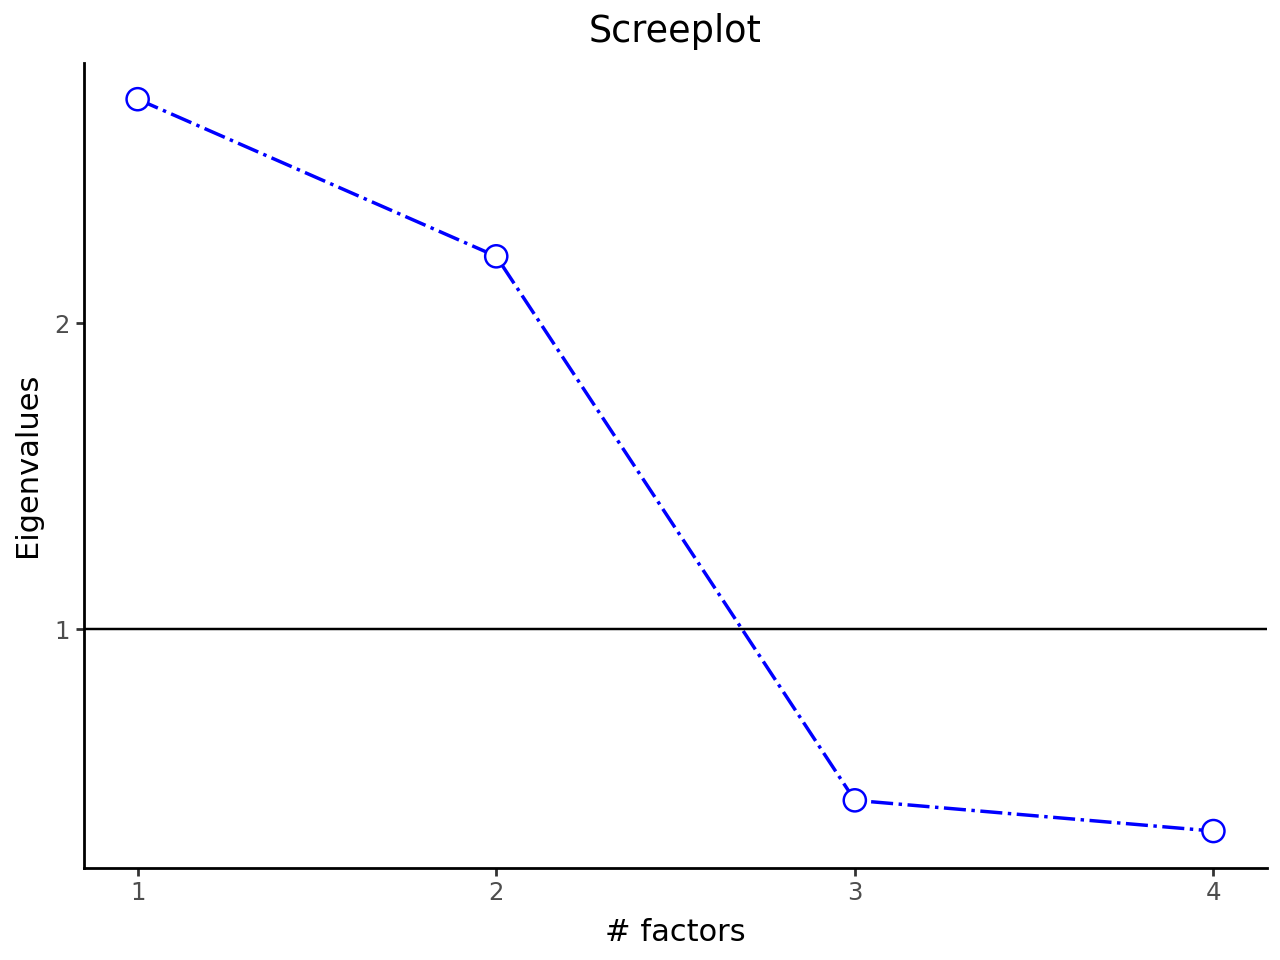

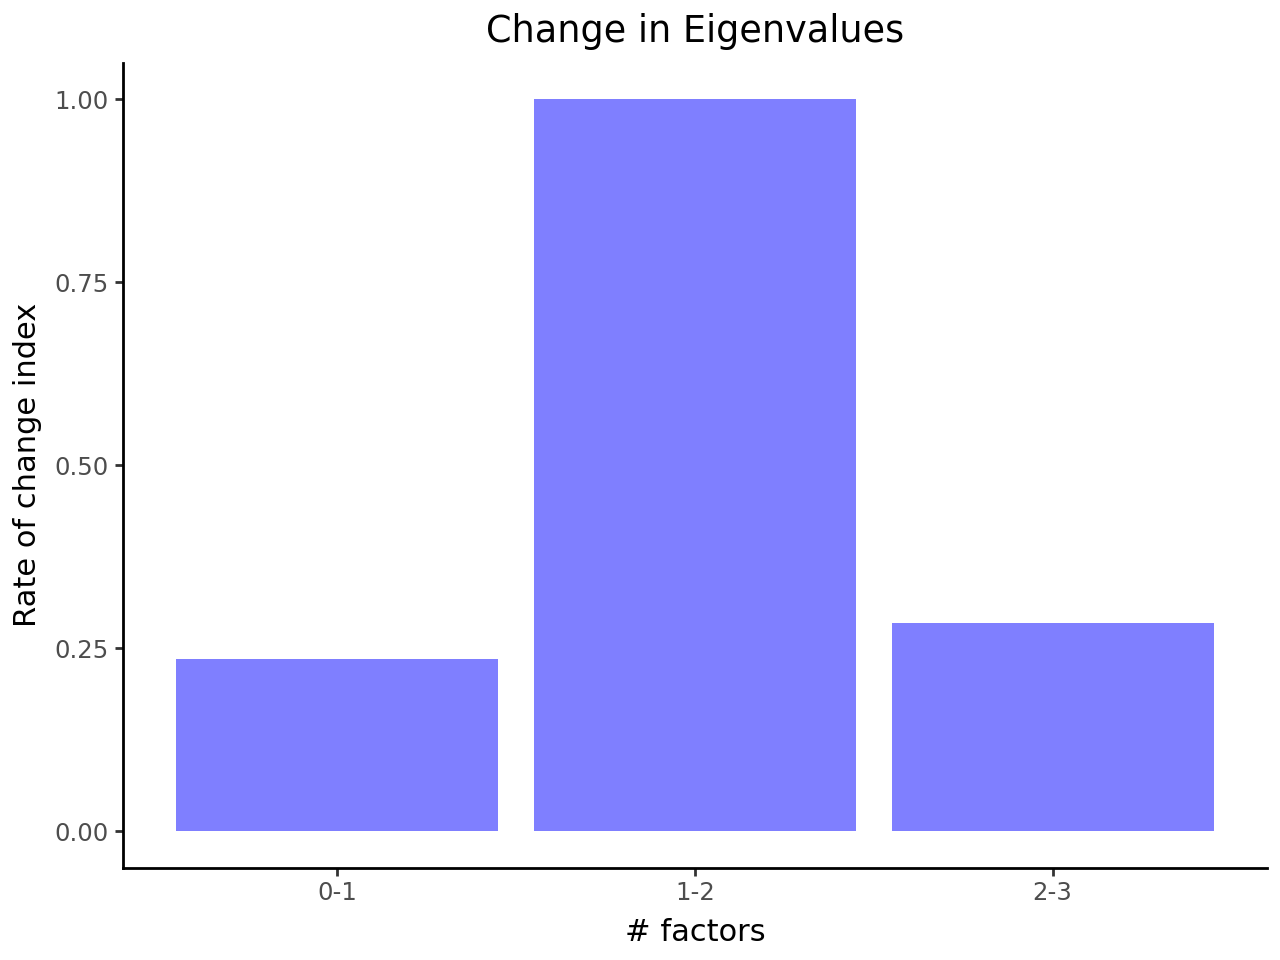

In [5]:
pf.plot(plots=("scree", "change"))

## Step 2 — Choose the Number of Factors and Estimate

Once we have determined the number of factors we can extract and rotate them. The factors are rotated to generate a solution where, to the extent possible, a variable has a high loading on only one factor. This is an important benefit because it makes it easier to interpret what the factor represents. While there are numerous algorithms to rotate a factor loadings matrix the most commonly used is Varimax rotation.

To replicate the standard toothpaste result, select variables `v1` through `v6`, set the number of factors to 2, and estimate. In `pyrsm` we pass the data as a dictionary (so the dataset name appears in the output), select the variables with the `v1:v6` range syntax, set `nr_fact=2`, and choose `rotation="varimax"`.

In [6]:
ff = rsm.multivariate.full_factor(
    {"toothpaste": toothpaste}, vars="v1:v6", nr_fact=2, rotation="varimax"
)
ff.summary(cutoff=0.4)

Factor analysis
Data        : toothpaste
Variables   : v1, v2, v3, v4, v5, v6
Factors     : 2
Method      : PCA
Rotation    : varimax
Observations: 60
Correlation : Pearson

Factor loadings:
shape: (6, 3)
┌─────┬───────┬──────┐
│     ┆ RC1   ┆ RC2  │
│ --- ┆ ---   ┆ ---  │
│ str ┆ str   ┆ str  │
╞═════╪═══════╪══════╡
│ v1  ┆ 0.96  ┆      │
│ v2  ┆       ┆ 0.85 │
│ v3  ┆ 0.93  ┆      │
│ v4  ┆       ┆ 0.85 │
│ v5  ┆ -0.93 ┆      │
│ v6  ┆       ┆ 0.88 │
└─────┴───────┴──────┘

Fit measures:
shape: (3, 3)
┌──────────────┬───────┬───────┐
│              ┆ RC1   ┆ RC2   │
│ ---          ┆ ---   ┆ ---   │
│ str          ┆ f64   ┆ f64   │
╞══════════════╪═══════╪═══════╡
│ Eigenvalues  ┆ 2.69  ┆ 2.26  │
│ Variance %   ┆ 44.78 ┆ 37.71 │
│ Cumulative % ┆ 44.78 ┆ 82.49 │
└──────────────┴───────┴───────┘

Attribute communalities:
shape: (6, 2)
┌─────┬──────┐
│     ┆      │
│ --- ┆ ---  │
│ str ┆ f64  │
╞═════╪══════╡
│ v1  ┆ 0.93 │
│ v2  ┆ 0.72 │
│ v3  ┆ 0.89 │
│ v4  ┆ 0.74 │
│ v5  ┆ 0.88 │
│ v

## Step 3 — Read the Loadings and Communalities

The numbers in the `Factor loadings` table are the correlations of the six variables with the two factors. For example, variable `v1` has a correlation of .96 with factor 1 and a correlation of -.03 with factor 2. As such `v1` will play a big role in naming factor 1 but an insignificant role in naming factor 2.

The `summary(cutoff=0.4)` call above already blanks out small loadings so the dominant factor for each variable stands out. To inspect the raw, un-cut loadings (every correlation, signed) use `loadings_frame`.

In [7]:
ff.loadings_frame(dec=3)

,RC1,RC2
str,f64,f64
"""v1""",0.962,-0.031
"""v2""",-0.053,0.848
"""v3""",0.933,-0.151
"""v4""",-0.094,0.855
"""v5""",-0.934,-0.079
"""v6""",0.088,0.885


Communalities give the share of each item's variance that is captured by the retained factors. High communalities mean the two-factor solution represents the original items well. The per-variable communalities are reported in the summary and are also available directly as an attribute.

In [8]:
ff.communality

array([0.92594449, 0.72274005, 0.89356726, 0.7391458 , 0.87779216,
       0.79011783])

The `Fit measures` table reports the eigenvalues, the variance percentage explained by each factor, and the cumulative percentage. The full set of eigenvalues of the correlation matrix (one per original variable) is also available directly — values above 1 are the ones used to justify the number of factors.

In [9]:
ff.eigen

array([2.73118833, 2.21811927, 0.44159791, 0.34125765, 0.18262823,
       0.08520861])

## Step 4 — Interpret and Name the Factors (and the Role of Rotation)

The rotated factor loadings can be used to determine labels or names for the different factors. We need to identify and highlight the highest factor loading, in absolute value, in each row. This is easily done by setting the cut-off value to .4 and sorting the factor loadings. The `clean_loadings` helper does both: it blanks loadings below the cut-off and (with `fsort=True`) groups the variables by the factor they load on.

In [10]:
rsm.multivariate.clean_loadings(ff.loadings_frame(), cutoff=0.4, fsort=True, repl="")

,RC1,RC2
str,str,str
"""v1""","""0.96175055""",""""""
"""v5""","""-0.93352886""",""""""
"""v3""","""0.93322362""",""""""
"""v6""","""""","""0.88455175"""
"""v4""","""""","""0.85456399"""
"""v2""","""""","""0.84848263"""


Together, the variables shown in each column (i.e., for each factor) help us to understand what the factor represents. Questions 1, 3, and 5 reflect the importance of health issues while questions 2, 4, and 6 reflect aesthetics issues (see the data description for a description of the variables). Plausible names for the factors might therefore be:

* **Factor 1:** Health benefits
* **Factor 2:** Social benefits

### What rotation does

The best way to see what rotation does is to switch between `varimax` and `none` in the `rotation` argument and inspect what changes in the output. With no rotation the loadings of the variables on the two factors are not aligned with the axes; with varimax rotation each variable lines up more cleanly with a single factor.

Variable `v5` is a good illustration. With no rotation `v5` falls somewhat in between the axes for factor 1 and factor 2. When we apply varimax rotation, the label for `v5` lines up nicely with the horizontal axis (i.e., factor 2). This change in alignment is also reflected in the factor loadings. The unrotated factor loadings for `v5` are about -0.87 for factor 1 and -0.35 for factor 2. The rotated factor loadings for `v5` are about -0.93 for factor 1 and -0.08 for factor 2.

In [11]:
ff_none = rsm.multivariate.full_factor(
    {"toothpaste": toothpaste}, vars="v1:v6", nr_fact=2, rotation="none"
)
ff_none.loadings_frame(dec=3)

,PC1,PC2
str,f64,f64
"""v1""",0.928,0.253
"""v2""",-0.301,0.795
"""v3""",0.936,0.131
"""v4""",-0.342,0.789
"""v5""",-0.869,-0.351
"""v6""",-0.177,0.871


The attribute loadings map shows each variable as a point/label in the factor space (the plot is square and centered at the origin, so distance and direction from the origin are comparable). Compare the unrotated map to the rotated one to _see_ how rotation moves the variables onto the axes.

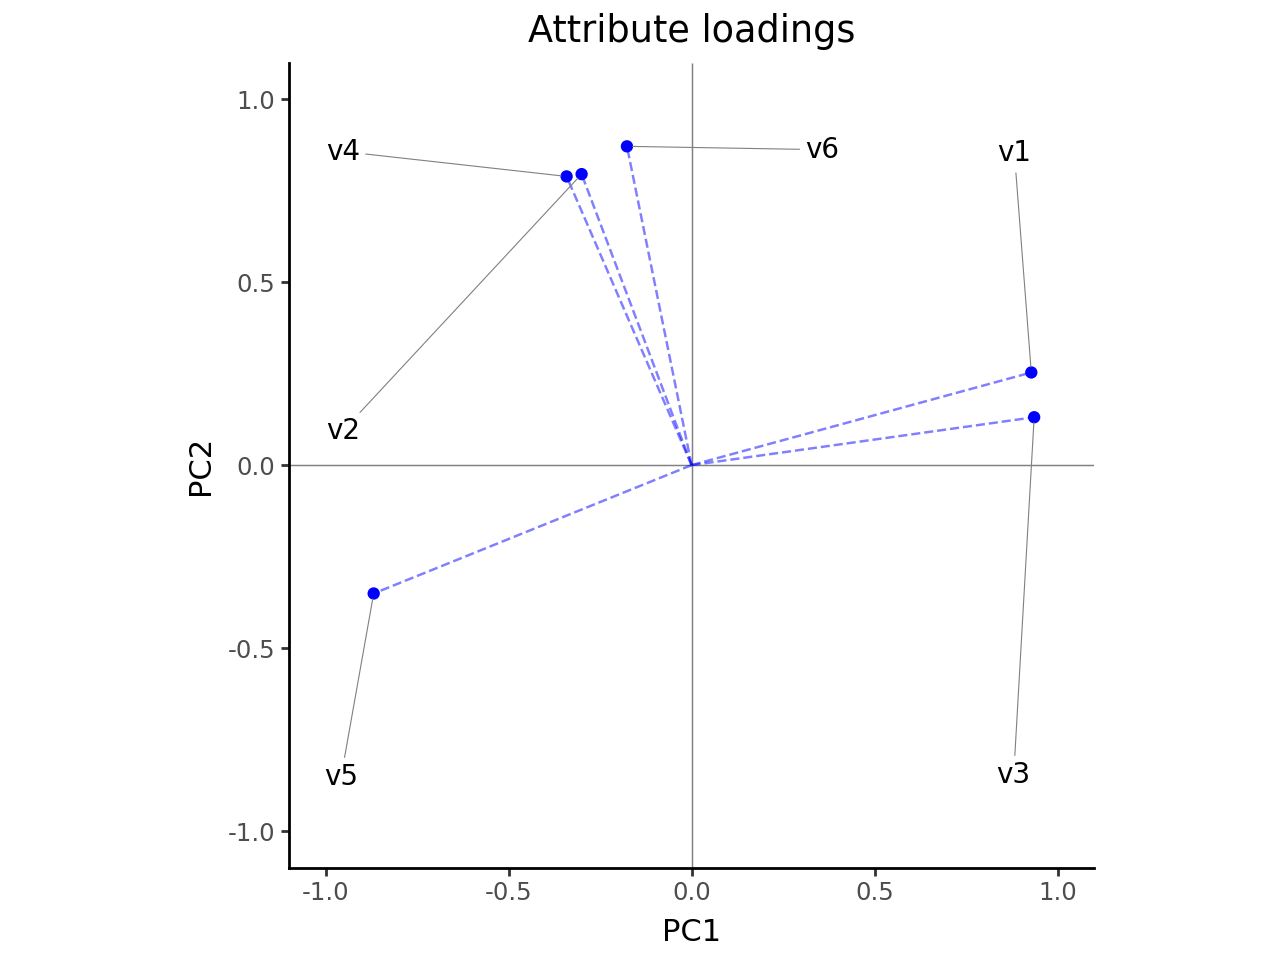

In [12]:
ff_none.plot(plots="attr")

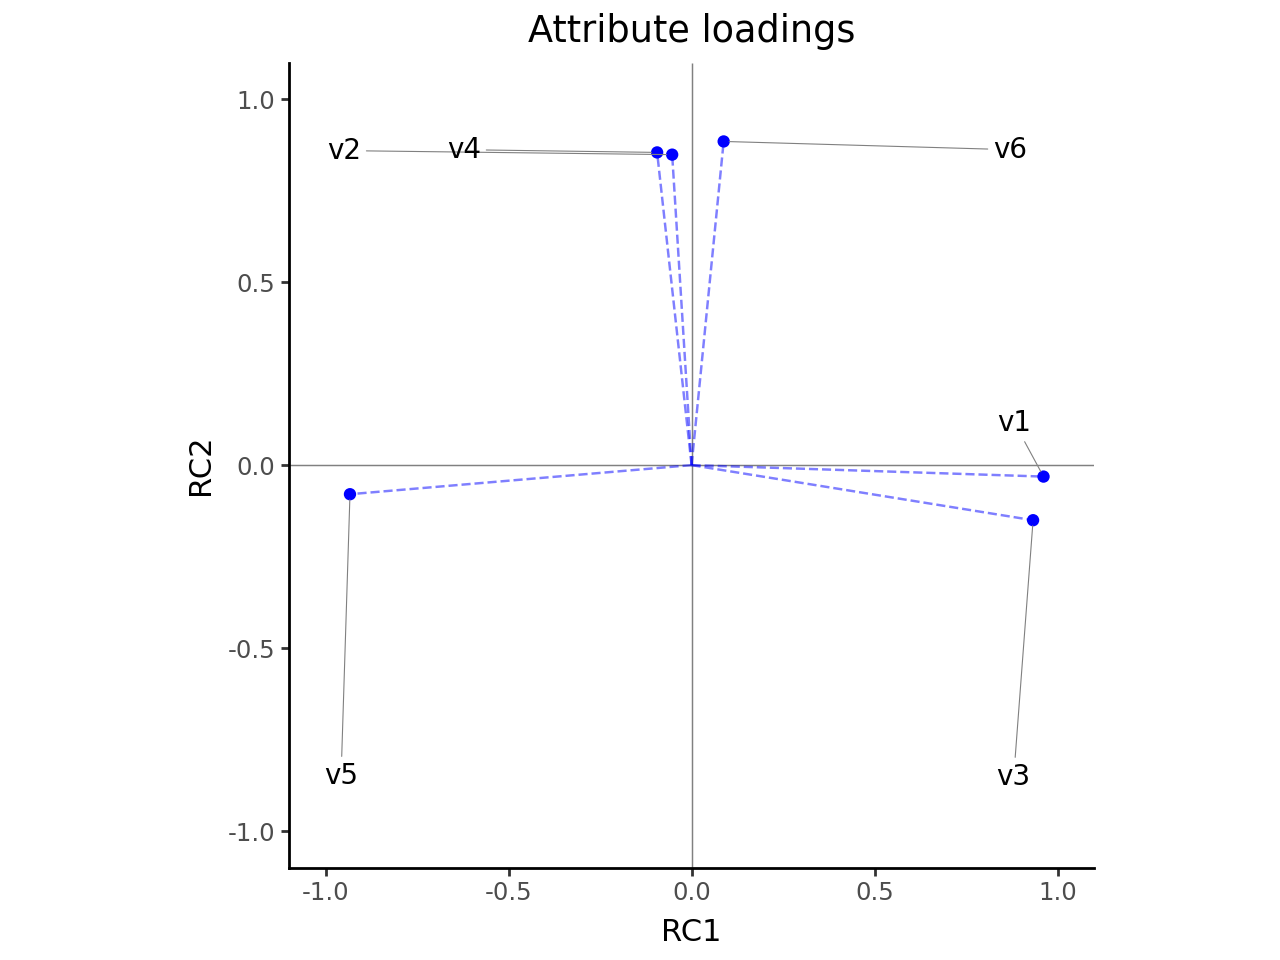

In [13]:
ff.plot(plots="attr")

We can also overlay the respondent scores (`resp`) on the attribute map. Each point is a respondent positioned by their factor scores, which makes it easy to see how the people and the items relate in the same space.

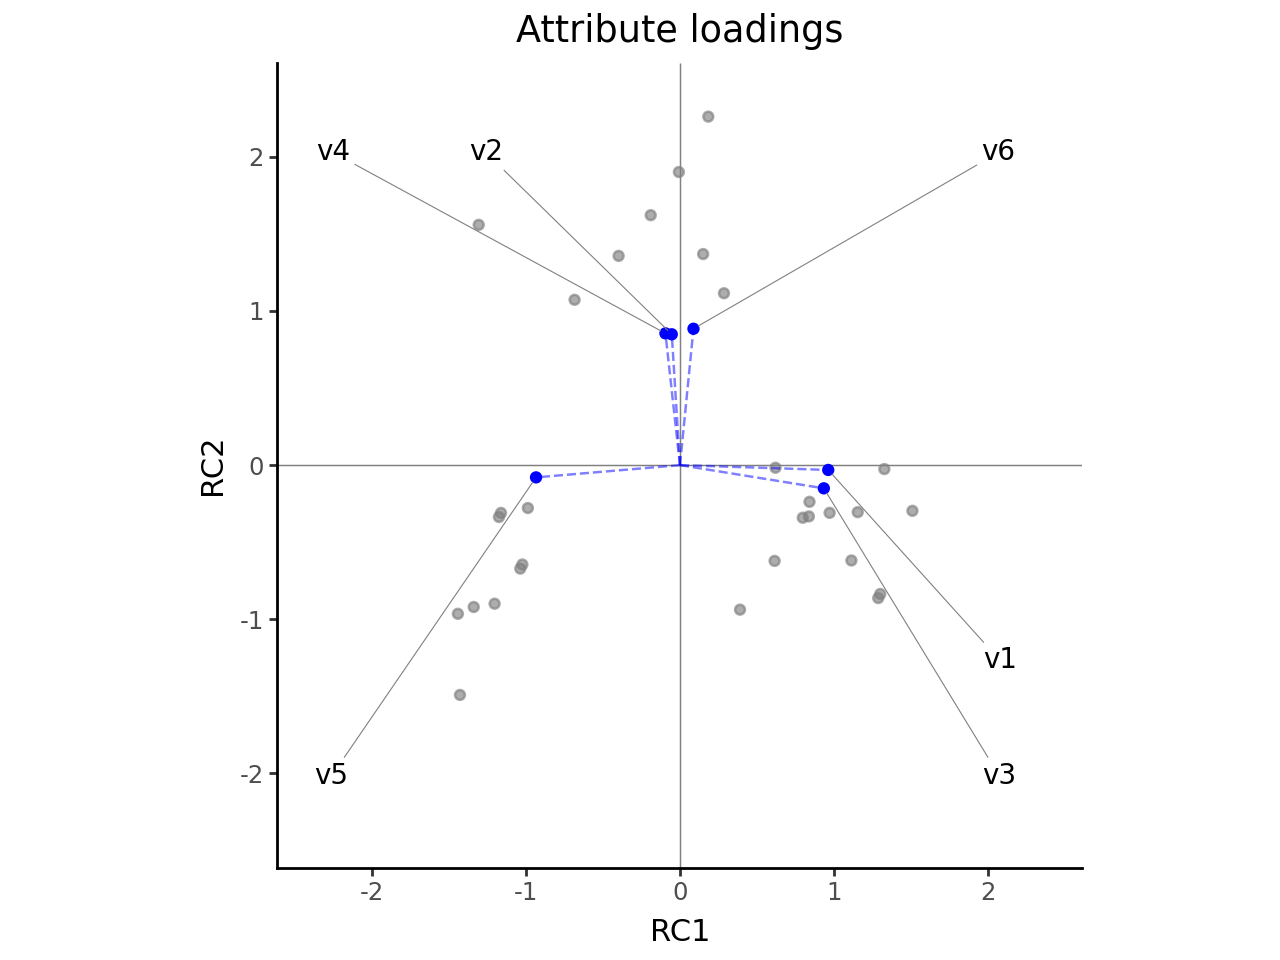

In [14]:
ff.plot(plots=["attr", "resp"])

### Other rotations

Varimax is the most common rotation, but `full_factor` supports several. `none`, `varimax`, and `quartimax` are orthogonal (factors stay uncorrelated); `oblimin` and `simplimax` are oblique (factors are allowed to correlate, which can fit naturally related constructs better). It is worth re-estimating with a couple of these to confirm the interpretation is stable.

In [15]:
for rot in ["none", "varimax", "quartimax", "oblimin", "simplimax"]:
    f = rsm.multivariate.full_factor(
        {"toothpaste": toothpaste}, "v1:v6", nr_fact=2, rotation=rot
    )
    print(f"rotation = {rot}")
    print(f.loadings_frame(dec=2))
    print()

rotation = none
shape: (6, 3)
┌─────┬───────┬───────┐
│     ┆ PC1   ┆ PC2   │
│ --- ┆ ---   ┆ ---   │
│ str ┆ f64   ┆ f64   │
╞═════╪═══════╪═══════╡
│ v1  ┆ 0.93  ┆ 0.25  │
│ v2  ┆ -0.3  ┆ 0.8   │
│ v3  ┆ 0.94  ┆ 0.13  │
│ v4  ┆ -0.34 ┆ 0.79  │
│ v5  ┆ -0.87 ┆ -0.35 │
│ v6  ┆ -0.18 ┆ 0.87  │
└─────┴───────┴───────┘

rotation = varimax
shape: (6, 3)
┌─────┬───────┬───────┐
│     ┆ RC1   ┆ RC2   │
│ --- ┆ ---   ┆ ---   │
│ str ┆ f64   ┆ f64   │
╞═════╪═══════╪═══════╡
│ v1  ┆ 0.96  ┆ -0.03 │
│ v2  ┆ -0.05 ┆ 0.85  │
│ v3  ┆ 0.93  ┆ -0.15 │
│ v4  ┆ -0.09 ┆ 0.85  │
│ v5  ┆ -0.93 ┆ -0.08 │
│ v6  ┆ 0.09  ┆ 0.88  │
└─────┴───────┴───────┘

rotation = quartimax
shape: (6, 3)
┌─────┬───────┬───────┐
│     ┆ RC1   ┆ RC2   │
│ --- ┆ ---   ┆ ---   │
│ str ┆ f64   ┆ f64   │
╞═════╪═══════╪═══════╡
│ v1  ┆ 0.96  ┆ -0.02 │
│ v2  ┆ -0.06 ┆ 0.85  │
│ v3  ┆ 0.94  ┆ -0.14 │
│ v4  ┆ -0.11 ┆ 0.85  │
│ v5  ┆ -0.93 ┆ -0.09 │
│ v6  ┆ 0.08  ┆ 0.89  │
└─────┴───────┴───────┘

rotation = oblimin
shape: (6, 3)
┌─

### Maximum likelihood extraction

Output shown in _Multivariate > Factor_ is estimated using either Principal Components Analysis (PCA, the default) or Maximum Likelihood (ML). PCA summarizes as much total variance as possible; ML models the common (shared) variance and supports statistical inference about the number of factors. Switch with the `method` argument.

In [16]:
ff_ml = rsm.multivariate.full_factor(
    {"toothpaste": toothpaste}, "v1:v6", nr_fact=2, method="ML"
)
ff_ml.loadings_frame(dec=3)

,RC1,RC2
str,f64,f64
"""v1""",0.968,-0.027
"""v2""",-0.048,0.749
"""v3""",0.898,-0.14
"""v4""",-0.085,0.784
"""v5""",-0.887,-0.089
"""v6""",0.051,0.83


## Step 5 — Store and Use the Factor Scores

The final step is to generate the factor scores. You can think of these scores as a weighted average of the variables that are linked to a factor. They approximate the scores that a respondent would have provided if we could have asked about the factor in a single question, i.e., the respondents' inferred ratings on the factors. Calling `store` returns the data with two new columns appended (`factor1` and `factor2`). We can use factor scores in other analyses (e.g., cluster analysis or regression). You can rename the new columns, e.g., to `health` and `social`, to make downstream work clearer.

In [17]:
scored = ff.store(toothpaste)
scored.head()

id,v1,v2,v3,v4,v5,v6,age,age.cat,gender,factor1,factor2
i32,i32,i32,i32,i32,i32,i32,i32,enum,enum,f64,f64
1,7,3,6,4,2,4,50,"""> 40""","""Female""",1.153257,-0.304955
2,1,3,2,4,5,4,27,"""< 30""","""Female""",-1.174109,-0.336415
3,6,2,7,4,1,3,24,"""< 30""","""Female""",1.286023,-0.862211
4,4,5,4,6,2,5,21,"""< 30""","""Female""",0.285469,1.114905
5,1,2,2,3,6,2,34,"""30 to 39""","""Female""",-1.426906,-1.490534


The raw scores are also available directly as a NumPy array (rows are respondents, columns are factors), along with the factor names.

In [18]:
print(ff.fnames)
ff.scores[:5]

['RC1', 'RC2']


array([[ 1.1532574 , -0.30495511],
       [-1.17410873, -0.33641471],
       [ 1.28602272, -0.86221096],
       [ 0.28546878,  1.11490497],
       [-1.42690616, -1.49053411]])

## Summary

1. Determine if the data are appropriate for factor analysis using Bartlett, KMO, and Collinearity (_Multivariate > Factor > Pre-factor_).
2. Determine the number of factors to extract using the scree-plot and eigenvalues > 1 criteria (_Multivariate > Factor > Pre-factor_).
3. Extract the (rotated) factor solution to produce:
    - Factor loadings: Correlations between attributes and factors.
    - Factor scores: Inferred ratings on the new factors (i.e., new variables that summarize the original variables).
4. Identify the highest factor loading, in absolute value, in each row (i.e., for each variable).
5. Label the factors using the strongest factor loadings.

## Practice — the Shopping Data

If you want more practice, open the `shopping` data set and see if you can reproduce a clean two-factor solution. Use the pre-factor diagnostics to determine whether the correct number of factors was selected. Do you agree? Why (not)?

In [19]:
shopping = pl.read_parquet(
    "https://github.com/radiant-ai-hub/pyrsm/raw/refs/heads/main/examples/data/multivariate/shopping.parquet"
)
ff_shop = rsm.multivariate.full_factor(
    {"shopping": shopping}, vars="v1:v6", nr_fact=2, rotation="varimax"
)
ff_shop.summary(cutoff=0.4)

Factor analysis
Data        : shopping
Variables   : v1, v2, v3, v4, v5, v6
Factors     : 2
Method      : PCA
Rotation    : varimax
Observations: 20
Correlation : Pearson

Factor loadings:
shape: (6, 3)
┌─────┬───────┬──────┐
│     ┆ RC1   ┆ RC2  │
│ --- ┆ ---   ┆ ---  │
│ str ┆ str   ┆ str  │
╞═════╪═══════╪══════╡
│ v1  ┆ 0.96  ┆      │
│ v2  ┆       ┆ 0.82 │
│ v3  ┆ 0.92  ┆      │
│ v4  ┆       ┆ 0.85 │
│ v5  ┆ -0.92 ┆      │
│ v6  ┆       ┆ 0.85 │
└─────┴───────┴──────┘

Fit measures:
shape: (3, 3)
┌──────────────┬───────┬───────┐
│              ┆ RC1   ┆ RC2   │
│ ---          ┆ ---   ┆ ---   │
│ str          ┆ f64   ┆ f64   │
╞══════════════╪═══════╪═══════╡
│ Eigenvalues  ┆ 2.66  ┆ 2.15  │
│ Variance %   ┆ 44.38 ┆ 35.86 │
│ Cumulative % ┆ 44.38 ┆ 80.24 │
└──────────────┴───────┴───────┘

Attribute communalities:
shape: (6, 2)
┌─────┬──────┐
│     ┆      │
│ --- ┆ ---  │
│ str ┆ f64  │
╞═════╪══════╡
│ v1  ┆ 0.92 │
│ v2  ┆ 0.68 │
│ v3  ┆ 0.86 │
│ v4  ┆ 0.75 │
│ v5  ┆ 0.87 │
│ v6 

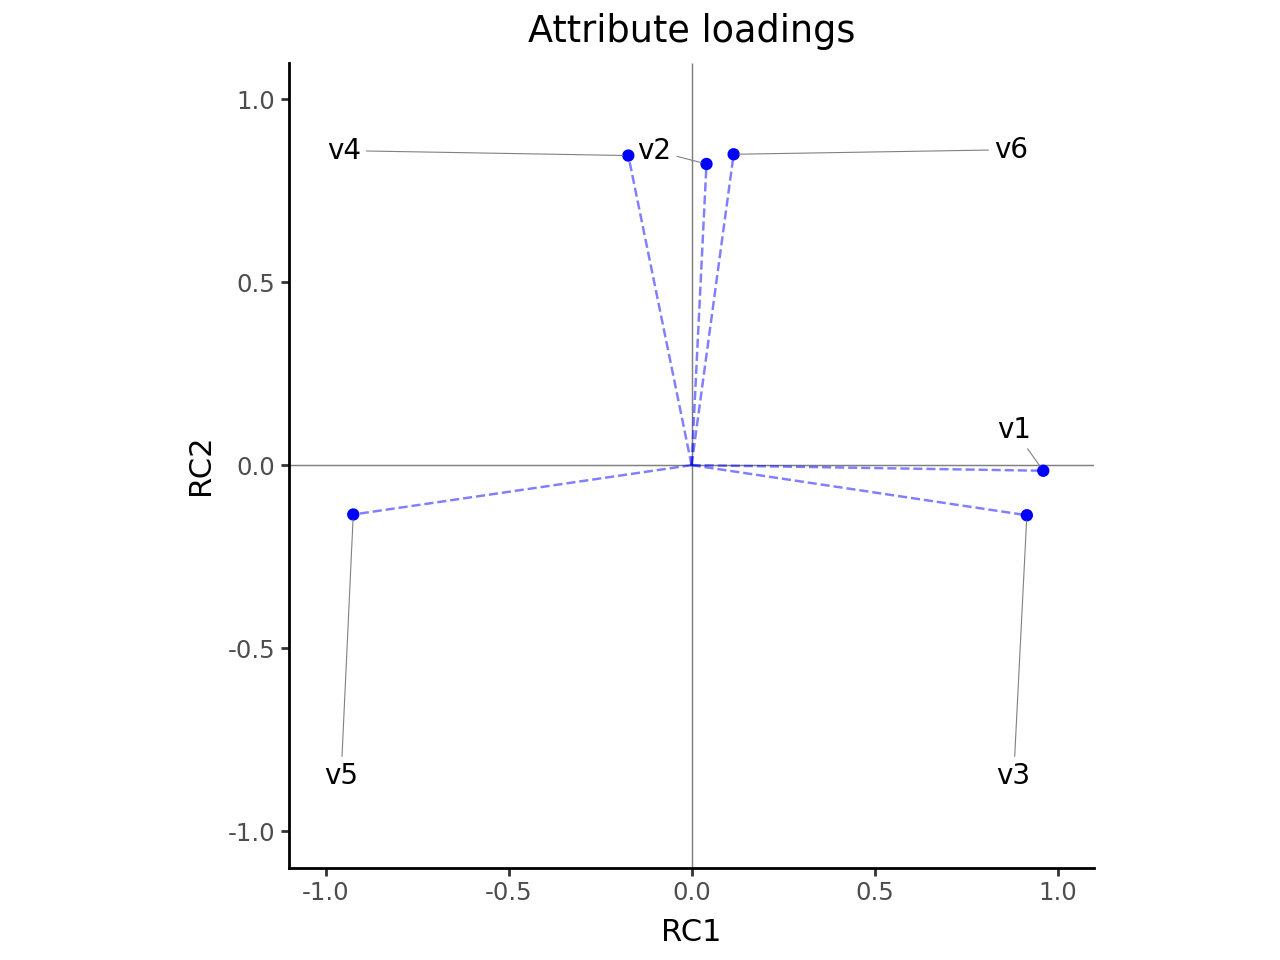

In [20]:
ff_shop.plot(plots="attr")

The shopping items split into the same kind of two-factor pattern as the toothpaste data: items `v1`, `v3`, `v5` group on one factor and `v2`, `v4`, `v6` on the other. With only 20 observations, however, the solution is far less stable than the toothpaste analysis — a good reminder to always check the pre-factor diagnostics and sample size before trusting the labels.

## Including Categorical Variables

The correlation matrix used as input for estimation can be calculated for variables of type numeric, integer, date, and factor (categorical). When categorical variables are included, set `hcor=True`. With this adjustment, variables that are categorical will be treated as (ordinal) categorical variables and all other variables will be treated as continuous, and the correlation matrix is built from polychoric/heterogeneous correlations instead of plain Pearson correlations.

In [21]:
levels = [str(x) for x in range(1, 8)]
ordinal = toothpaste.with_columns(
    [pl.col(f"v{i}").cast(pl.Utf8).cast(pl.Enum(levels)) for i in range(1, 7)]
)

ff_poly = rsm.multivariate.full_factor(
    {"toothpaste": ordinal}, "v1:v6", nr_fact=2, hcor=True
)
ff_poly.loadings_frame(dec=3)

,RC1,RC2
str,f64,f64
"""v1""",0.958,0.04
"""v2""",-0.062,0.819
"""v3""",0.931,-0.073
"""v4""",-0.08,0.799
"""v5""",-0.938,-0.043
"""v6""",0.146,0.87


It is important to note that estimated factor scores will be biased if a mix of categorical and numeric variables is used. If you want to use factor scores as input for further analysis, e.g., clustering, you should use either (1) all categorical variables or (2) all numeric variables to avoid this bias.

### Filtering the data

`full_factor` also accepts a `data_filter` argument so you can fit the model on a subset of rows without changing the underlying data — useful for comparing factor structures across groups.

In [22]:
ff_female = rsm.multivariate.full_factor(
    {"toothpaste": toothpaste},
    "v1:v6",
    nr_fact=2,
    rotation="varimax",
    data_filter="gender == 'Female'",
)
ff_female.loadings_frame(dec=3)

,RC1,RC2
str,f64,f64
"""v1""",0.954,-0.178
"""v2""",-0.225,0.861
"""v3""",0.918,-0.306
"""v4""",-0.232,0.909
"""v5""",-0.931,0.12
"""v6""",-0.077,0.888


## Discussion Prompts

* Which items define each factor, and does any item load meaningfully on both?
* What substantive names would you give the factors, and how confident are you in those labels?
* What are the limitations? The sample is small, factor labels come from researcher judgment, and factors summarize patterns of association rather than proving an underlying psychological cause.

### Related functions

The key estimation routines used by the `full_factor` tool are principal-components analysis and maximum-likelihood factor analysis. The Python implementation mirrors the behavior of the `principal` and `fa` functions from the R `psych` package used in Radiant.